# `gwtf` quickstart

This notebook contains a minimal example for generating waveforms or inner products in the time-frequency domain with `gwtf`.

In [78]:
import matplotlib.pyplot as plt
import numpy as np

from pygwtf.generator import AnalyticTimeFrequencyWaveform
from pygwtf.models import TaylorT2Ecc

In [96]:
# Define the parameters for the time-frequency grid
dT = 86400 / 4  # 6 hours # SFT time. 
nT = 365 * 4  # 1 year # Number of SFT time bins in the total observation 
dt = 5 # time step for the *time-domain* data -> used to determine fmax for the SFT 
dF = 1 / dT # Frequency spacing within the SFT. 
# 1/(2*dt) is the Nyquist frequency for the time-domain data
fmax = 1 / (2 * dt) # Nyquist frequency for the time-domain data

nF = int((fmax)/ dF) + 1 # Number of frequency bins needed to cover the Nyquist frequency.

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 10,  # Number of frequency bins to use in the fresnel kernel 
}

First, let's look at the transverse-traceless polarisations. This is set by passing `tdi_type=None` (the default).

In [97]:
generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,   
    tdi_type=None,
)

Spacecraft light travel times not supplied. Falling back to analytic calculation


We can generate waveforms by calling the generator.

In [98]:
generator.model.parameters

['M', 'eta', 'cosi', 'e0', 'D', 'f0', 'phi_coal']

In [99]:
pars = {
    "M": 30,
    "eta": 0.25,
    "cosi": 0.5,
    "e0": 1e-3,
    "D": 1e3,
    "f0": 4e-2,
    "phi_coal": 0.1,
}

# This contains the time-frequency representation of the waveform. 
tf = generator(pars)


The shape of the data object ```tf``` is ```(# SFT Times, # SFT frequencies, # {h_plus/cross})```

In [100]:
tf.shape

(1460, 2161, 2)

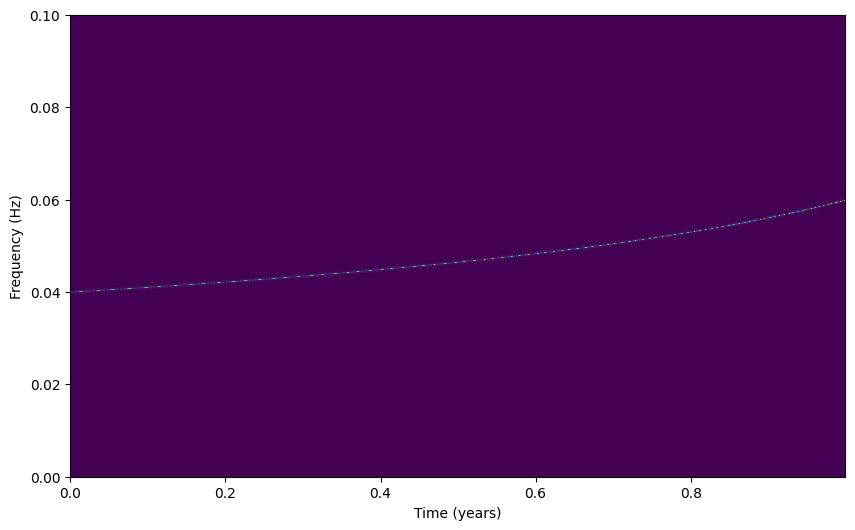

In [101]:
plt.figure(figsize=(10, 6))
plt.pcolormesh(generator.t_tranche/(365.25*24*3600), generator.f_tranche, np.abs(tf[:, :, 0].T))
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.show()

Waveforms for multiple sources can be generated by passing 1-d arrays. We'll add the results together for plotting:

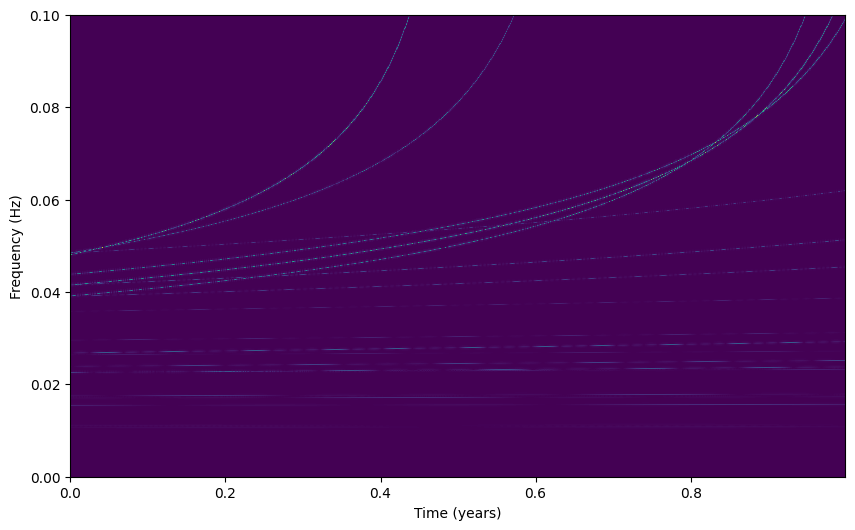

In [102]:
rng = np.random.default_rng(1729)
pars = {
    "M": rng.uniform(20, 50, size=20),
    "eta": rng.uniform(0.1, 0.25, size=20),
    "cosi": rng.uniform(0, 1, size=20),
    "e0": rng.uniform(1e-4, 1e-2, size=20),
    "D": rng.uniform(1e3, 1e3, size=20),
    "f0": rng.uniform(1e-2, 5e-2, size=20),
    "phi_coal": rng.uniform(0, 1, size=20),
}

# the object returned now has an extra dimension on the very outside, so the dimensionality is now
# (nsources, nT,nF, 2)

# the sum over the sources is the superposition of the time-frequency representations of the individual sources. 
tf = generator(pars).sum(0)
plt.figure(figsize=(10, 6))
plt.pcolormesh(generator.t_tranche/(365.25*24*3600), generator.f_tranche, np.abs(tf[:, :, 0].T))
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.show()

We can also construct the complex noise-weighted inner product over tranches. We chose to generate the complex inner product and then let the user determine what to do with it, this adds flexibility as the user can construct phase-maximised quantities, or to take the real part and compute the usual noise-weighted inner product.<br><br>
Let's demonstrate for those signals (assuming a flat PSD for now). Note that the returned inner products $\langle d \mid h \rangle$ and $\langle h \mid h \rangle$ will be essentially equal here as no noise is present:

In [103]:
rng = np.random.default_rng(1729)

# Parameter for the inner product computation, batched over 20 sources.
pars_stat = pars.copy()

# NOTE: In the following, the 'channels' argument is providing the time-frequency representation of the data 
#       which in this case is identical to the generated signals.
tf_stat = generator(
    pars_stat,
    channels=tf,
    psds=np.ones_like(tf) * 1e-34, # Flat PSD
    compute_statistic=True, # Flag to return the inner-products instead of the time-frequency representation of the waveform.
)

#NOTE: For the purposes of this example we are pretending we can get a PSD directly on h_plus/cross.
print("Shape of the returned statistic:", tf_stat.shape)

# Shape is (nsources, nT, 2 (h_h and d_h))) because we have computed the inner products for each source separately.


Shape of the returned statistic: (20, 1460, 2)


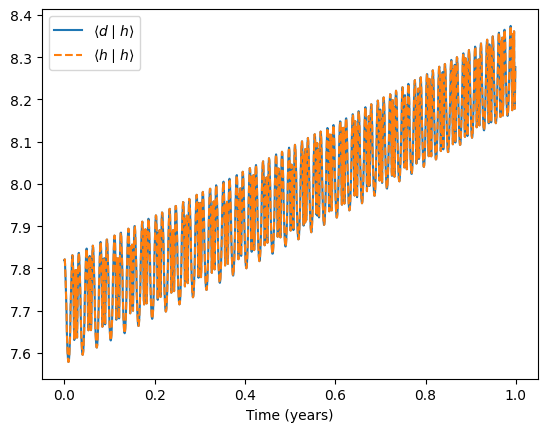

In [106]:
plt.plot(generator.t_tranche/(365.25*24*3600), np.real(tf_stat[0, :, 0]), label=r'$\langle d \mid h \rangle$')
plt.plot(generator.t_tranche/(365.25*24*3600), np.real(tf_stat[0, :, 1]), ls="--", label=r'$\langle h \mid h \rangle$')
plt.xlabel("Time (years)")
# plt.xlim(0, 1)
plt.legend()

Note that if you broaden the number of fresnel bins to be used in the statistic computation (within the config defined near the beginning of the notebook), you will notice that $\langle d \mid h \rangle$ will diverge from $\langle h \mid h \rangle$, however this is completely expected. What is happening here is the cross term of $\langle h(\theta_1) \mid h(\theta_2) \rangle$ is non-negligible over 6 hour time-scales, however you will observe that if you sum $\langle d \mid h \rangle$ across all the time segments (which can be used to compute the actual equivalent of the matched filter SNR over the whole obsevation), orthogonality is restored, and the $\langle h(\theta_1) \mid h(\theta_2) \rangle$ terms contribute effectively 0. 

## TDI generation

We can also generate TDI variables. Right now it just generates the AET channels. You can choose the TDI generation and the spacecraft orbit information (passed as an array of shape `(nT, 3, 3)`). The latter falls back on Keplerian analytic orbits if not provided.

In [108]:
tdi_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=2,
)

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation


We also have to pass response/extrinsic parameters parameters here.

In [111]:
pars = {
    "M": 30,
    "eta": 0.25,
    "cosi": 0.5,
    "e0": 1e-3,
    "D": 1e3,#pc 
    "f0": 4e-2,
    "phi_coal": 0.1,
}

parameters_response = np.array(
    [
        [
            pars["cosi"],
            np.pi / 6,  # polarization
            5 * np.pi / 4,  # ecliptic longitude
            np.pi / 3,  # ecliptic latitude
        ]
    ]
)

tf_tdi = tdi_generator(pars, parameters_response=parameters_response)


In [112]:
tf_tdi.shape

(1460, 2161, 3)

The shape of ```tf_tdi``` is now ```(#nT,#nF,#{AET})```

Text(0, 0.5, 'Frequency (Hz)')

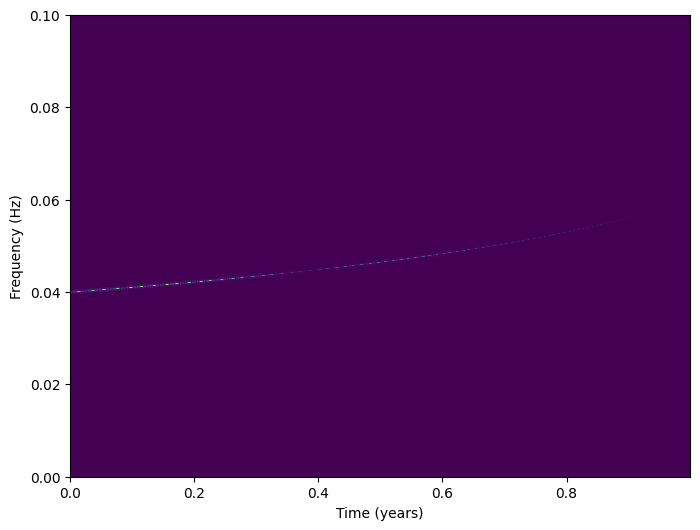

In [115]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(
    generator.t_tranche/(365.25*24*3600), generator.f_tranche, np.abs(tf_tdi[:, :, 0].T)
)
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")

The previously mentioned inner-products can of course also be directly computed for the TDI channels directly as demonstrated below for one source $\langle d \mid h \rangle$ as a function of time is shown, to get the value for $\langle d \mid h \rangle$ over the whole evolution, just the sum across all times of this quantity is needed:

<function matplotlib.pyplot.show(close=None, block=None)>

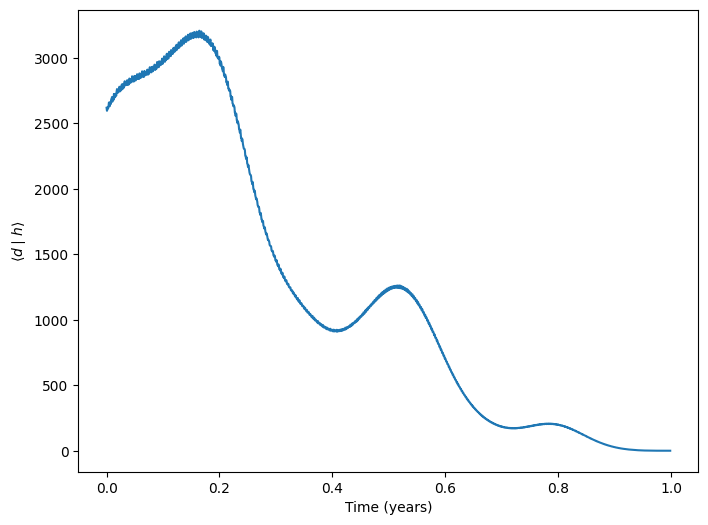

In [120]:
tf_tdi_stat = tdi_generator(
    pars,
    channels=tf_tdi,
    psds=np.ones_like(tf) * 1e-34,
    parameters_response=parameters_response,
    compute_statistic=True,
)

plt.figure(figsize=(8, 6))
plt.plot(generator.t_tranche/(365.25*24*3600),tf_tdi_stat[:, 0].real)
plt.xlabel("Time (years)")
plt.ylabel(r'$\langle d \mid h \rangle$')
plt.show
